In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sbn
from sklearn.metrics import roc_auc_score

In [2]:
res = pd.read_csv('~/merged_edges_evaluation.csv', low_memory=False)
res.head(5) 

,func_node,output_node,aggregated_score,output_node_raw,hold_out_known_edge
0,PROTEIN__AAK1,AARS,0.6,NaN,False
1,PROTEIN__AAK1,ABCB6,0.8,NaN,False
2,PROTEIN__AAK1,ABCC5,0.6,NaN,False
3,PROTEIN__AAK1,ABCF1,0.5,NaN,False
4,PROTEIN__AAK1,ABCF3,0.3,NaN,False


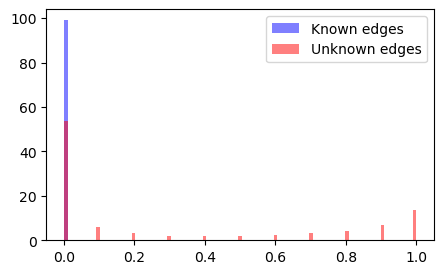

In [3]:
_bins = np.linspace(0, 1, 100)

plt.figure(figsize=(5, 3))
plt.hist(res[lambda x: x.hold_out_known_edge].aggregated_score, bins=_bins, color='b', alpha=0.5, label='Known edges', density=True)
plt.hist(res[lambda x: ~x.hold_out_known_edge].aggregated_score, bins=_bins, color='r', alpha=0.5, label='Unknown edges', density=True)
plt.legend()
plt.show()


In [4]:
res0 = pd.read_csv('~/oei_sample0.csv', low_memory=False)
res0.head(5)


,Unnamed: 0,func_node,output_node,mse,r2,r,has_edge,p_value,snr,l1_norm,...,model_r,model_mse,r2_gain,r_gain,mse_gain,q_value,snr_rank,sparsity_rank,within_output_rank,dxdt_dir
0,0,PROTEIN__TP53,GENE__INTS3,0.448816,0.765627,0.882031,False,0.0,3.277848,4.372764,...,0.044609,1.911276,0.763702,0.837422,-1.462460,0.0,1,1,1,/home/exacloud/gscratch/mcweeney_lab/evans/lin...
1,1,PROTEIN__ETS1,GENE__INTS3,0.466773,0.756249,0.877480,False,0.0,3.164856,7.202007,...,0.044609,1.911276,0.754324,0.832872,-1.444502,0.0,2,2,2,/home/exacloud/gscratch/mcweeney_lab/evans/lin...
2,2,PROTEIN__E2F1,GENE__INTS3,0.485597,0.746420,0.872650,False,0.0,2.954499,6.944879,...,0.044609,1.911276,0.744495,0.828041,-1.425679,0.0,3,3,3,/home/exacloud/gscratch/mcweeney_lab/evans/lin...
3,3,PROTEIN__MYC,GENE__INTS3,0.488681,0.744809,0.870851,False,0.0,2.837995,6.091381,...,0.044609,1.911276,0.742884,0.826242,-1.422595,0.0,6,6,6,/home/exacloud/gscratch/mcweeney_lab/evans/lin...
4,4,PROTEIN__AR,GENE__INTS3,0.488981,0.744653,0.870013,False,0.0,2.906746,5.166598,...,0.044609,1.911276,0.742728,0.825405,-1.422295,0.0,4,4,4,/home/exacloud/gscratch/mcweeney_lab/evans/lin...


In [5]:
holdout = pd.read_csv('~/removed_edges.csv', low_memory=False)
holdout = holdout[['src_name', 'dst_name']].assign(hold_out_edge = True)
holdout = holdout.assign(dst_name_gene = [x.split('__')[1] for x in holdout.dst_name])
holdout.head(5)

,src_name,dst_name,hold_out_edge,dst_name_gene
0,PROTEIN__GATA3,RNA__MBNL2,True,MBNL2
1,PROTEIN__FOS,RNA__MBNL2,True,MBNL2
2,PROTEIN__CEBPA,RNA__CDK2,True,CDK2
3,PROTEIN__E2F4,RNA__CDK2,True,CDK2
4,PROTEIN__RELA,RNA__CDK4,True,CDK4


In [6]:
res0 = res0.assign(output_gene = [x.split('__')[1] for x in res0.output_node])

res0 = res0.merge(holdout, left_on=['func_node', 'output_gene'], right_on=['src_name', 'dst_name_gene'], how='left')

res0.head() 



,Unnamed: 0,func_node,output_node,mse,r2,r,has_edge,p_value,snr,l1_norm,...,q_value,snr_rank,sparsity_rank,within_output_rank,dxdt_dir,output_gene,src_name,dst_name,hold_out_edge,dst_name_gene
0,0,PROTEIN__TP53,GENE__INTS3,0.448816,0.765627,0.882031,False,0.0,3.277848,4.372764,...,0.0,1,1,1,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,INTS3,NaN,NaN,NaN,NaN
1,1,PROTEIN__ETS1,GENE__INTS3,0.466773,0.756249,0.877480,False,0.0,3.164856,7.202007,...,0.0,2,2,2,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,INTS3,NaN,NaN,NaN,NaN
2,2,PROTEIN__E2F1,GENE__INTS3,0.485597,0.746420,0.872650,False,0.0,2.954499,6.944879,...,0.0,3,3,3,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,INTS3,NaN,NaN,NaN,NaN
3,3,PROTEIN__MYC,GENE__INTS3,0.488681,0.744809,0.870851,False,0.0,2.837995,6.091381,...,0.0,6,6,6,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,INTS3,NaN,NaN,NaN,NaN
4,4,PROTEIN__AR,GENE__INTS3,0.488981,0.744653,0.870013,False,0.0,2.906746,5.166598,...,0.0,4,4,4,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,INTS3,NaN,NaN,NaN,NaN


In [7]:
assert (res0.hold_out_edge.values == True).sum() == holdout.shape[0], 'missing edges after merge'

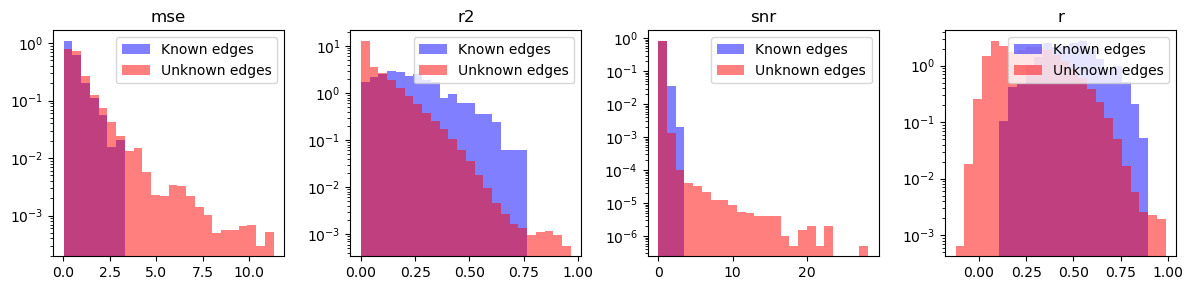

In [8]:
f, axes = plt.subplots(1, 4, figsize=(12, 3))

for i, metric in enumerate(['mse', 'r2', 'snr', 'r']):
    _min = res0[metric].min(); _max = res0[metric].max()
    _bins = np.linspace(_min, _max, 25)
    axes[i].hist(res0[lambda x: x.hold_out_edge == True][metric], bins=_bins, color='b', alpha=0.5, label='Known edges', density=True)
    axes[i].hist(res0[lambda x: x.hold_out_edge.isna()][metric], bins=_bins, color='r', alpha=0.5, label='Unknown edges', density=True)
    axes[i].legend()
    axes[i].set_title(metric)
    axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

In [9]:

score = res0[lambda x: ~x.has_edge].r.values
label = res0[lambda x: ~x.has_edge].hold_out_edge.fillna(False).values

roc_auc_score(label, score)

/tmp/ipykernel_32112/4252597924.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  label = res0[lambda x: ~x.has_edge].hold_out_edge.fillna(False).values


0.8397810852630524

In [10]:
metric = 'r2_gain'

ranks = [] 
for i,row in res0[lambda x: x.hold_out_edge == True].reset_index().iterrows():
    print(f'progress: {i}/{res0[lambda x: x.hold_out_edge == True].shape[0]}', end='\r')

    negatives = res0[lambda x: x.hold_out_edge.isna() & (x.output_node == row.output_node)][metric].values
    positives = row[metric] 
    rank = (negatives >= positives).sum() + 1 
    ranks.append(rank)

ranks = np.array(ranks)


In [11]:
n_func_nodes = res0.func_node.nunique() 
print(f'n_func_nodes: {n_func_nodes}')

n_func_nodes: 1727


In [12]:
np.mean(1/ranks)

np.float64(0.04959148166797371)

In [13]:
top_at_1 = (ranks <= 1).mean()
top_at_10 = (ranks <= 10).mean()
top_at_100 = (ranks <= 100).mean()
top_at_250 = (ranks <= 250).mean()
top_at_500 = (ranks <= 500).mean()

print(f'top_at_1: {top_at_1}')
print(f'top_at_10: {top_at_10}')
print(f'top_at_100: {top_at_100}')
print(f'top_at_250: {top_at_250}')
print(f'top_at_500: {top_at_500}')

top_at_1: 0.0
top_at_10: 0.14492753623188406
top_at_100: 0.5579710144927537
top_at_250: 0.6980676328502415
top_at_500: 0.857487922705314


In [14]:
res0_rand = res0.copy()
res0_rand.hold_out_edge = np.random.permutation(res0_rand.hold_out_edge)

ranks_rand = [] 
for i,row in res0_rand[lambda x: x.hold_out_edge == True].reset_index().iterrows():
    print(f'progress: {i}/{res0_rand[lambda x: x.hold_out_edge == True].shape[0]}', end='\r')

    negatives = res0_rand[lambda x: x.hold_out_edge.isna() & (x.output_node == row.output_node)][metric].values
    positives = row[metric] 
    rank = (negatives >= positives).sum() + 1 
    ranks_rand.append(rank)

ranks_rand = np.array(ranks_rand)


In [15]:
np.mean(1/ranks_rand)

np.float64(0.008605956084989324)

In [16]:
top_at_1_rand = (ranks_rand <= 1).mean()
top_at_10_rand = (ranks_rand <= 10).mean()
top_at_100_rand = (ranks_rand <= 100).mean()
top_at_250_rand = (ranks_rand <= 250).mean()
top_at_500_rand = (ranks_rand <= 500).mean()

print(f'top_at_1: {top_at_1_rand}')
print(f'top_at_10: {top_at_10_rand}')
print(f'top_at_100: {top_at_100_rand}')
print(f'top_at_250: {top_at_250_rand}')
print(f'top_at_500: {top_at_500_rand}')

top_at_1: 0.0024154589371980675
top_at_10: 0.012077294685990338
top_at_100: 0.07246376811594203
top_at_250: 0.14492753623188406
top_at_500: 0.30917874396135264


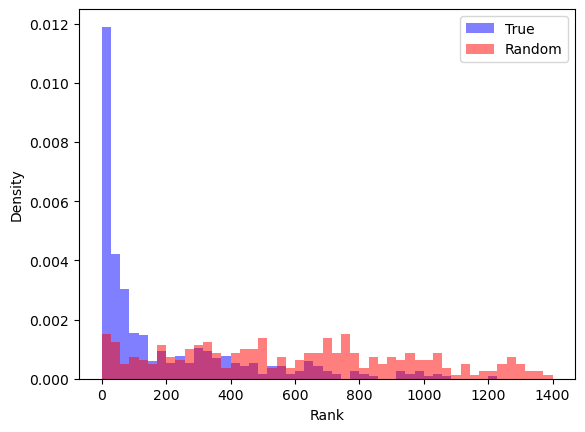

In [17]:
_bins = np.linspace(0, 1400, 50)

plt.figure()
plt.hist(ranks, bins=_bins, density=True, color='b', alpha=0.5, label='True')
plt.hist(ranks_rand, bins=_bins, density=True, color='r', alpha=0.5, label='Random')
plt.xlabel('Rank')
plt.ylabel('Density')
plt.legend()
plt.show() 

In [18]:
resa = pd.read_csv('~/avg_inferred_edge_results.csv', low_memory=False)
resa = resa.assign(output_gene = [x.split('__')[1] for x in resa.output_node])
resa = resa.merge(holdout, left_on=['func_node', 'output_gene'], right_on=['src_name', 'dst_name_gene'], how='left')
resa = resa[['func_node', 'output_node', 'snr', 'r2_gain', 'r_gain', 'hold_out_edge']]
resa.hold_out_edge = resa.hold_out_edge.fillna(False)
resa.head()


/tmp/ipykernel_32112/1132870212.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  resa.hold_out_edge = resa.hold_out_edge.fillna(False)


,func_node,output_node,snr,r2_gain,r_gain,hold_out_edge
0,PROTEIN__AAK1,GENE__AARS,0.001109,-0.015921,-0.083784,False
1,PROTEIN__AAK1,GENE__ABCB6,0.000385,-0.011882,-0.083878,False
2,PROTEIN__AAK1,GENE__ABCC5,0.000294,-0.123799,-0.286734,False
3,PROTEIN__AAK1,GENE__ABCF1,0.000819,-0.016682,-0.127454,False
4,PROTEIN__AAK1,GENE__ABCF3,0.001262,-0.024828,-0.102591,False


In [19]:
metric = 'r2_gain'

ranks = [] 
for i,row in resa[lambda x: x.hold_out_edge == True].reset_index().iterrows():
    print(f'progress: {i}/{resa[lambda x: x.hold_out_edge == True].shape[0]}', end='\r')

    negatives = resa[lambda x: ~x.hold_out_edge & (x.output_node == row.output_node)][metric].values
    positives = row[metric] 
    rank = (negatives >= positives).sum() + 1 
    ranks.append(rank)

ranks = np.array(ranks)

In [20]:
np.mean(1/ranks)

np.float64(0.07709005087527236)

In [21]:
top_at_1 = (ranks <= 1).mean()
top_at_10 = (ranks <= 10).mean()
top_at_100 = (ranks <= 100).mean()
top_at_250 = (ranks <= 250).mean()
top_at_500 = (ranks <= 500).mean()

print(f'top_at_1: {top_at_1}')
print(f'top_at_10: {top_at_10}')
print(f'top_at_100: {top_at_100}')
print(f'top_at_250: {top_at_250}')
print(f'top_at_500: {top_at_500}')


top_at_1: 0.0175
top_at_10: 0.21
top_at_100: 0.64
top_at_250: 0.7525
top_at_500: 0.8375


In [22]:
resa_rand = resa.copy()
resa_rand.hold_out_edge = np.random.permutation(resa_rand.hold_out_edge)

ranks_rand = [] 
for i,row in resa_rand[lambda x: x.hold_out_edge == True].reset_index().iterrows():
    print(f'progress: {i}/{resa_rand[lambda x: x.hold_out_edge == True].shape[0]}', end='\r')

    negatives = resa_rand[lambda x: ~x.hold_out_edge & (x.output_node == row.output_node)][metric].values
    positives = row[metric] 
    rank = (negatives >= positives).sum() + 1 
    ranks_rand.append(rank)

ranks_rand = np.array(ranks_rand)

In [23]:
np.mean(1/ranks_rand)

np.float64(0.005903000650615907)

In [ ]:

mrr = np.mean(1/ranks_rand)

top_at_1_rand = (ranks_rand <= 1).mean()
top_at_10_rand = (ranks_rand <= 10).mean()
top_at_100_rand = (ranks_rand <= 100).mean()
top_at_250_rand = (ranks_rand <= 250).mean()
top_at_500_rand = (ranks_rand <= 500).mean()

print(f'top_at_1: {top_at_1_rand}')
print(f'top_at_10: {top_at_10_rand}')
print(f'top_at_100: {top_at_100_rand}')
print(f'top_at_250: {top_at_250_rand}')
print(f'top_at_500: {top_at_500_rand}')

top_at_1: 0.0
top_at_10: 0.0125
top_at_100: 0.08
top_at_250: 0.1975
top_at_500: 0.3425


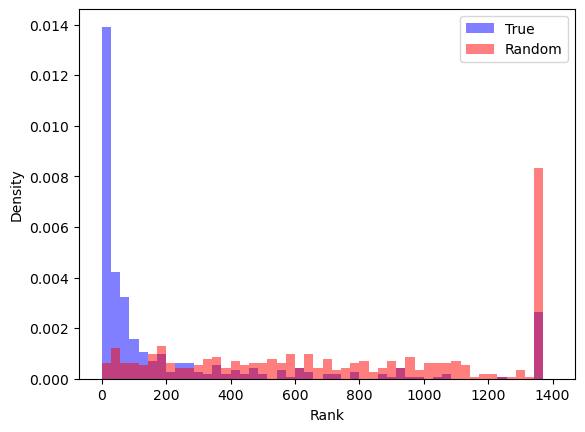

In [25]:
#_bins = np.logspace(np.log10(1), np.log10(1800), 10)
_bins = np.linspace(0, 1400, 50)

plt.figure()
plt.hist(ranks, bins=_bins, density=True, color='b', alpha=0.5, label='True')
plt.hist(ranks_rand, bins=_bins, density=True, color='r', alpha=0.5, label='Random')
plt.xlabel('Rank')
plt.ylabel('Density')
plt.legend()
plt.show() 

# Can we use the model performance to suggest nodes that have greater "need" 


In [29]:
res0.head() 

,Unnamed: 0,func_node,output_node,mse,r2,r,has_edge,p_value,snr,l1_norm,...,q_value,snr_rank,sparsity_rank,within_output_rank,dxdt_dir,output_gene,src_name,dst_name,hold_out_edge,dst_name_gene
0,0,PROTEIN__TP53,GENE__INTS3,0.448816,0.765627,0.882031,False,0.0,3.277848,4.372764,...,0.0,1,1,1,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,INTS3,NaN,NaN,NaN,NaN
1,1,PROTEIN__ETS1,GENE__INTS3,0.466773,0.756249,0.877480,False,0.0,3.164856,7.202007,...,0.0,2,2,2,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,INTS3,NaN,NaN,NaN,NaN
2,2,PROTEIN__E2F1,GENE__INTS3,0.485597,0.746420,0.872650,False,0.0,2.954499,6.944879,...,0.0,3,3,3,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,INTS3,NaN,NaN,NaN,NaN
3,3,PROTEIN__MYC,GENE__INTS3,0.488681,0.744809,0.870851,False,0.0,2.837995,6.091381,...,0.0,6,6,6,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,INTS3,NaN,NaN,NaN,NaN
4,4,PROTEIN__AR,GENE__INTS3,0.488981,0.744653,0.870013,False,0.0,2.906746,5.166598,...,0.0,4,4,4,/home/exacloud/gscratch/mcweeney_lab/evans/lin...,INTS3,NaN,NaN,NaN,NaN


In [60]:
res0.columns

Index(['Unnamed: 0', 'func_node', 'output_node', 'mse', 'r2', 'r', 'has_edge',
       'p_value', 'snr', 'l1_norm', 'l2_norm', 'sparsity', 'eff_rank',
       'model_r2', 'model_r', 'model_mse', 'r2_gain', 'r_gain', 'mse_gain',
       'q_value', 'snr_rank', 'sparsity_rank', 'within_output_rank',
       'dxdt_dir', 'output_gene', 'src_name', 'dst_name', 'hold_out_edge',
       'dst_name_gene', 'r2_scaled_by_l1'],
      dtype='object')

/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


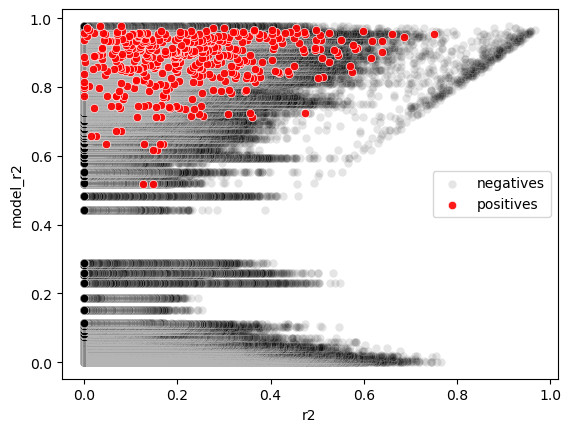

In [ ]:
plt.figure() 
sbn.scatterplot(x='r2', y='model_r2', color='k', alpha=0.1, data=res0[lambda x: x.hold_out_edge.isna()])
sbn.scatterplot(x='r2', y='model_r2', color='r', alpha=0.9, data=res0[lambda x: x.hold_out_edge == True])
plt.show() 


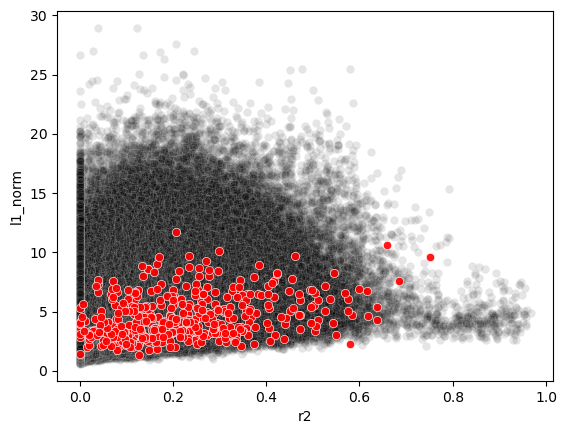

In [46]:
plt.figure() 
sbn.scatterplot(x='r2', y='l1_norm', color='k', alpha=0.1, data=res0[lambda x: x.hold_out_edge.isna()])
sbn.scatterplot(x='r2', y='l1_norm', color='r', alpha=0.9, data=res0[lambda x: x.hold_out_edge == True])
plt.show() 

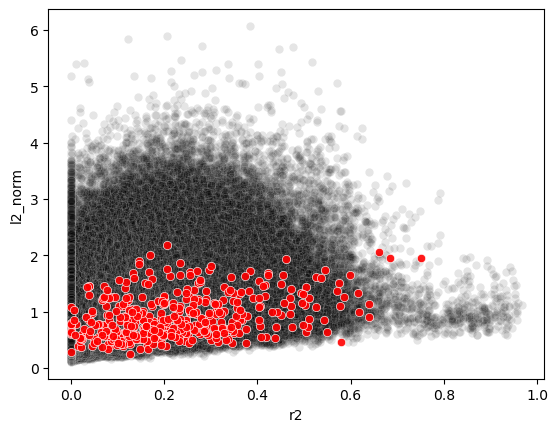

In [70]:
plt.figure() 
sbn.scatterplot(x='r2', y='l2_norm', color='k', alpha=0.1, data=res0[lambda x: x.hold_out_edge.isna()])
sbn.scatterplot(x='r2', y='l2_norm', color='r', alpha=0.9, data=res0[lambda x: x.hold_out_edge == True])
plt.show() 

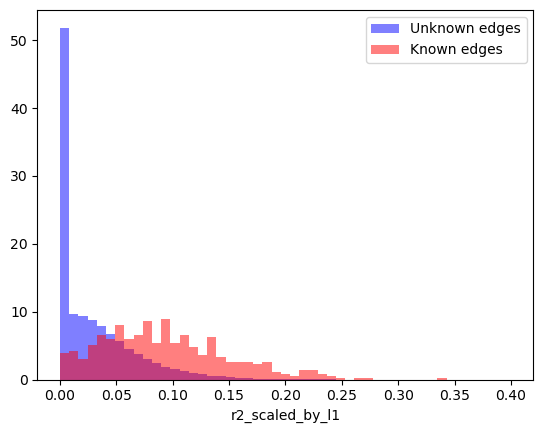

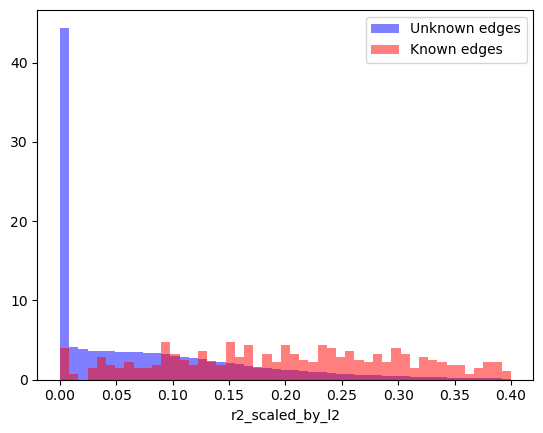

In [71]:
res0 = res0.assign(r2_scaled_by_l1 = (res0.r2 / (np.log2(res0.l1_norm + 1) + 1e-8))) 
res0 = res0.assign(r2_scaled_by_l2 = (res0.r2 / (np.log2(res0.l2_norm + 1) + 1e-8))) 

_bins = np.linspace(0, 0.4, 50)

plt.figure()  
plt.hist(res0[lambda x: x.hold_out_edge.isna()].r2_scaled_by_l1, bins=_bins, color='b', alpha=0.5, label='Unknown edges', density=True)
plt.hist(res0[lambda x: x.hold_out_edge == True].r2_scaled_by_l1, bins=_bins, color='r', alpha=0.5, label='Known edges', density=True)
plt.legend() 
#plt.yscale('log')
plt.xlabel('r2_scaled_by_l1')
plt.show() 

plt.figure()  
plt.hist(res0[lambda x: x.hold_out_edge.isna()].r2_scaled_by_l2, bins=_bins, color='b', alpha=0.5, label='Unknown edges', density=True)
plt.hist(res0[lambda x: x.hold_out_edge == True].r2_scaled_by_l2, bins=_bins, color='r', alpha=0.5, label='Known edges', density=True)
plt.legend() 
#plt.yscale('log')
plt.xlabel('r2_scaled_by_l2')
plt.show() 

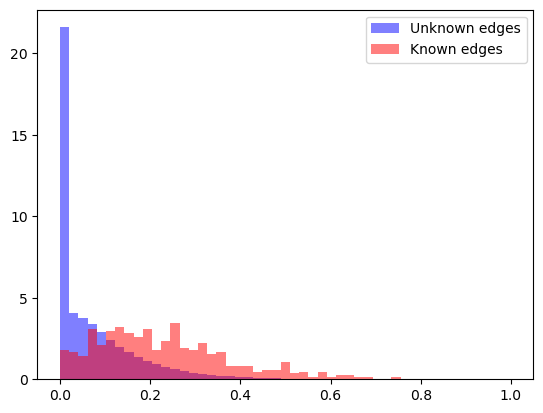

In [72]:
_bins = np.linspace(0, 1., 50)

plt.figure()  
plt.hist(res0[lambda x: x.hold_out_edge.isna()].r2, bins=_bins, color='b', alpha=0.5, label='Unknown edges', density=True)
plt.hist(res0[lambda x: x.hold_out_edge == True].r2, bins=_bins, color='r', alpha=0.5, label='Known edges', density=True)
plt.legend() 
#plt.yscale('log')
plt.show() 

In [73]:
scores = res0.r2_scaled_by_l1.values
labels = res0.hold_out_edge.fillna(False).astype(int)

roc_auc_score(labels, scores)

/tmp/ipykernel_32112/3193375491.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  labels = res0.hold_out_edge.fillna(False).astype(int)


0.8495129009291746

In [74]:
scores = res0.r2_scaled_by_l2.values
labels = res0.hold_out_edge.fillna(False).astype(int)

roc_auc_score(labels, scores)

/tmp/ipykernel_32112/1520916068.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  labels = res0.hold_out_edge.fillna(False).astype(int)


0.850053861298913

In [75]:
scores = res0.r2.values
labels = res0.hold_out_edge.fillna(False).astype(int)

roc_auc_score(labels, scores)

/tmp/ipykernel_32112/2342518455.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  labels = res0.hold_out_edge.fillna(False).astype(int)


0.8393019512034129

In [76]:
metric = 'r2_scaled_by_l1'

ranks = [] 
for i,row in res0[lambda x: x.hold_out_edge == True].reset_index().iterrows():
    print(f'progress: {i}/{res0[lambda x: x.hold_out_edge == True].shape[0]}', end='\r')

    negatives = res0[lambda x: x.hold_out_edge.isna() & (x.output_node == row.output_node)][metric].values
    positives = row[metric] 
    rank = (negatives >= positives).sum() + 1 
    ranks.append(rank)

ranks = np.array(ranks)


In [78]:
mrr = np.mean(1/ranks)

top_at_1 = (ranks <= 1).mean()
top_at_10 = (ranks <= 10).mean()
top_at_100 = (ranks <= 100).mean()
top_at_250 = (ranks <= 250).mean()
top_at_500 = (ranks <= 500).mean()

print(f'mrr: {mrr}')
print(f'top_at_1: {top_at_1}')
print(f'top_at_10: {top_at_10}')
print(f'top_at_100: {top_at_100}')
print(f'top_at_250: {top_at_250}')
print(f'top_at_500: {top_at_500}')

mrr: 0.050394063364912506
top_at_1: 0.0
top_at_10: 0.15217391304347827
top_at_100: 0.5966183574879227
top_at_250: 0.7318840579710145
top_at_500: 0.8623188405797102
